# 2.2.1 从平均变化到导数

## 学习目标与先修知识

能用差商（difference quotient）解释导数（derivative）的含义和单位，区分有限区间斜率（slope）、局部斜率与浮点计算误差。

先修：上一章的变化量与持续时间、函数图像。 [复习上一节](../01-用递推描述增长与清除/02-让时间进入收支更新.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

人工累积曲线 A(t)=t² 在 t=1 附近变得有多快？观测（observation）区间越短，平均变化率是否越来越接近同一个数？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()

## 初步实验

先按给定条件计算，再用后面的推导解释结果。

In [2]:
hs = [1,.5,.1,.01]
display(Markdown(show_table(['h / T','平均变化率 / (U/T)'], [(h,((1+h)**2-1)/h) for h in hs])))

| h / T | 平均变化率 / (U/T) |
| --- | --- |
| 1 | 3 |
| 0.5 | 2.5 |
| 0.1 | 2.1 |
| 0.01 | 2.01 |

## 模型假设

为单独观察数学关系，先指定一条无噪声曲线 $A(t)=c t^2$，$c=1\;U/T^2$。代码中 t 是以 T 为单位的数值，A 的结果以 U 为单位。

## 数学解释与推导

平均变化率是两个端点连成的割线（secant line）斜率：
$$\frac{A(t+h)-A(t)}h.$$
当 h 趋近零，如果这个商趋近一个确定值，就把它定义为 t 处的导数：
$$A'(t)=\frac{dA}{dt}=\lim_{h\to0}\frac{A(t+h)-A(t)}h.$$
“趋近”讨论一系列非零 h；直接代入零会得到 0/0。切线（tangent line）表达曲线在该点的局部变化方向。导数的单位是 U/T，与流率（flow rate）相同；不是这个点已经拥有的所追踪物质总量（tracked amount）。

对本例先展开再约分：
$$\frac{(t+h)^2-t^2}{h}=\frac{2th+h^2}{h}=2t+h\longrightarrow2t.$$
所以在 t=1，导数为 2；任何有限正 h 的差商都比它大 h。常数导数为零，$at+b$ 的导数为 a，和的导数等于各项导数之和；这些规则可分别从差商展开得到。

实际计算还受有限精度限制。数学上 h 越小越接近极限（limit），电脑里两个近乎相等的数相减可能丢失有效数字，再除以 h 放大误差。应该观察误差随 h 的变化，而不是只选机器能表示的最小数。

## 核心实现

函数只接收本节定义的量；核心计算步骤如下。

In [3]:
def forward_difference(t, h):
    return ((t + h)**2 - t**2) / h

## 对照实验

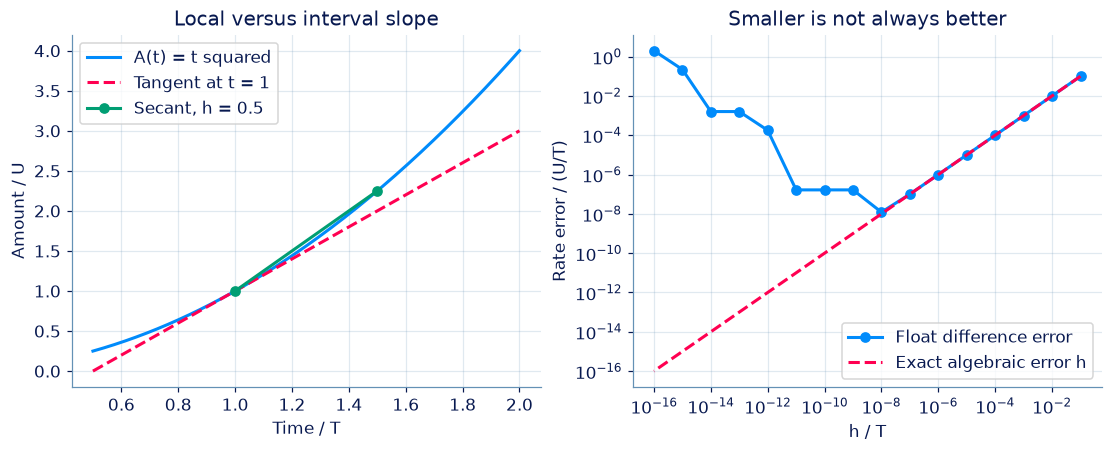

In [4]:
fig, axes=plt.subplots(1,2,figsize=(10,4))
times=np.linspace(.5,2,200)
axes[0].plot(times,times**2,label='A(t) = t squared')
axes[0].plot(times,1+2*(times-1),'--',label='Tangent at t = 1')
axes[0].plot([1,1.5],[1,2.25],'o-',label='Secant, h = 0.5')
axes[0].set(xlabel='Time / T',ylabel='Amount / U',title='Local versus interval slope');axes[0].legend()
small=np.logspace(-1,-16,16)
err=np.array([abs(forward_difference(1,float(h))-2) for h in small])
axes[1].loglog(small,np.maximum(err,1e-18),'o-',label='Float difference error')
axes[1].loglog(small,small,'--',label='Exact algebraic error h')
axes[1].set(xlabel='h / T',ylabel='Rate error / (U/T)',title='Smaller is not always better');axes[1].legend()
plt.show()

## 结果解释

左图的割线平均了 1—1.5 T 的变化，切线只描述 t=1 附近。右图先接近代数误差 h，极小时偏离；显示用 1e−18 作为对数图下限，不改变原计算。当 h 极小时，相近数相减会放大浮点舍入的影响，数值误差（numerical error）因而偏离原来的下降趋势。

### 独立核对

核对的是本例可展开的精确表达，不用另一遍相同差分充当独立参考。

In [5]:
for t,h in [(0,.5),(1,.1),(3,.001)]:
    assert math.isclose(forward_difference(t,h),2*t+h,abs_tol=1e-10)
assert abs(forward_difference(1,.01)-2)<abs(forward_difference(1,.1)-2)
print('差商与展开后的独立表达一致；合理区间内近似误差随 h 减小。')

差商与展开后的独立表达一致；合理区间内近似误差随 h 减小。


## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 多项选择题：平均变化与局部变化

人工曲线 A(t)=t² U，t 的数值以 T 为单位。区间 [1,1+h] 的差商（difference quotient）为 (A(1+h)−A(1))/h。哪些说法正确？

- **A.** 它的单位是 U/T。
- **B.** 当 h=0.5 T 时它等于 2.5 U/T。
- **C.** 任意非零 h 得到的数都恰好等于 t=1 的导数（derivative）。
- **D.** h 趋近零时差商趋近 2 U/T。

[作答：平均变化与局部变化](http://127.0.0.1:8000/chapters/02-02-%E5%8F%98%E5%8C%96%E7%8E%87%E4%B8%8E%E7%B4%AF%E7%A7%AF%EF%BC%9A%E5%BE%AE%E7%A7%AF%E5%88%86%E5%85%A5%E5%8F%A3/practice/?question=p02-slope-meaning)

### 第 2 题 · Python 计算题：用差商接近局部斜率

给定 A(t)=t²，直接按前向差分计算位置 t 的平均变化率，不返回精确导数（derivative） 2t。t、h 是以 T 为单位的数值。

**函数与代码模板**

```python
def solve(
    t: float,
    h: float,
) -> float:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `t` | `float` | 差分区间左端。 | T |
| `h` | `float` | 区间长度。 | T |

**返回值**

直接返回 rate（float）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rate` | `float` | [t,t+h] 上的平均变化率。 | U/T |

**计算规则**

返回 ((t+h)\*\*2 − t\*\*2) / h。

**约束与边界**

- 所有数值有限；无需修改输入（input）。
- 0 ≤ t ≤ 10；1e−4 ≤ h ≤ 1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| t | 差分区间左端。 | 1 | T |
| h | 区间长度。 | 0.5 | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
t = 1
h = 0.5

result = solve(t, h)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rate | [t,t+h] 上的平均变化率。 | 2.5 | U/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 2.5
```

**样例解释**

(1.5²−1²)/0.5=2.5；比精确导数 2 大 0.5。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：用差商接近局部斜率](http://127.0.0.1:8000/chapters/02-02-%E5%8F%98%E5%8C%96%E7%8E%87%E4%B8%8E%E7%B4%AF%E7%A7%AF%EF%BC%9A%E5%BE%AE%E7%A7%AF%E5%88%86%E5%85%A5%E5%8F%A3/practice/?question=p02-difference)

### 第 3 题 · 单项选择题：趋近零与代入零

定义导数（derivative）时，让 h 趋近零而不直接取零，主要原因是什么？

- **A.** 因为函数永远不能在 t=0 取值。
- **B.** 因为差商（difference quotient）分母为 h，直接取零通常得到 0/0。
- **C.** 因为电脑不允许任何零数值。
- **D.** 因为导数只是随意选一个很小的 h。

[作答：趋近零与代入零](http://127.0.0.1:8000/chapters/02-02-%E5%8F%98%E5%8C%96%E7%8E%87%E4%B8%8E%E7%B4%AF%E7%A7%AF%EF%BC%9A%E5%BE%AE%E7%A7%AF%E5%88%86%E5%85%A5%E5%8F%A3/practice/?question=p02-limit-not-zero)

### 第 4 题 · 单项选择题：更小间隔总是更准确吗

用浮点数对光滑曲线做差分。h 缩小时，一开始误差减小，后来却变大。最合理的解释是？

- **A.** 导数（derivative）不存在。
- **B.** 所有差分方法必定不收敛。
- **C.** 相近数相减的舍入误差（round-off error）经除以很小的 h 放大。
- **D.** 应把所有结果取整。

[作答：更小间隔总是更准确吗](http://127.0.0.1:8000/chapters/02-02-%E5%8F%98%E5%8C%96%E7%8E%87%E4%B8%8E%E7%B4%AF%E7%A7%AF%EF%BC%9A%E5%BE%AE%E7%A7%AF%E5%88%86%E5%85%A5%E5%8F%A3/practice/?question=p02-difference-noise)

**进一步阅读**

[MIT 导数入门](https://ocw.mit.edu/courses/18-01sc-single-variable-calculus-fall-2010/pages/1.-differentiation/part-a-definition-and-basic-rules/session-1-introduction-to-derivatives/)：变化率与差商。